In [1]:
import pandas as pd
from IPython.display import display, Markdown
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
# import dash
# from dash import html, dcc
# from dash.dependencies import Output, Input, State
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier


df_original = pd.read_csv("/content/commercial_planning.csv", encoding="latin-1")

display(Markdown("### Estructura y consistencia de los datos"))
info_df = pd.DataFrame({
    "Tipo de dato": df_original.dtypes,
    "Registros no nulos": df_original.notnull().sum(),
    "Valores faltantes (%)": (df_original.isnull().sum() / len(df_original) * 100).round(2)
})
display(info_df)

display(Markdown("-" * 70))

final_states = ["CLOSED", "COMPLETE", "CANCELED", "SUSPECTED_FRAUD"]
df_original = df_original[df_original["Order Status"].isin(final_states)]
df_original["Order Success"] = df_original["Order Status"].isin(["COMPLETE", "CLOSED"]).astype(int)

display(Markdown(f"#### Variable 'Order Status': {df_original["Order Status"].unique()} ---> Variable Target 'Order Success': {df_original["Order Success"].unique()}"))

### Estructura y consistencia de los datos

,Tipo de dato,Registros no nulos,Valores faltantes (%)
Days for shipment (scheduled),int64,180519,0.0
Category Name,object,180519,0.0
Market,object,180519,0.0
Order Item Discount,float64,180519,0.0
Order Item Profit Ratio,float64,180519,0.0
Order Region,object,180519,0.0
Order Status,object,180519,0.0
Product Price,float64,180519,0.0
Shipping Mode,object,180519,0.0


----------------------------------------------------------------------

#### Variable 'Order Status': ['COMPLETE' 'CLOSED' 'CANCELED' 'SUSPECTED_FRAUD'] ---> Variable Target 'Order Success': [1 0]

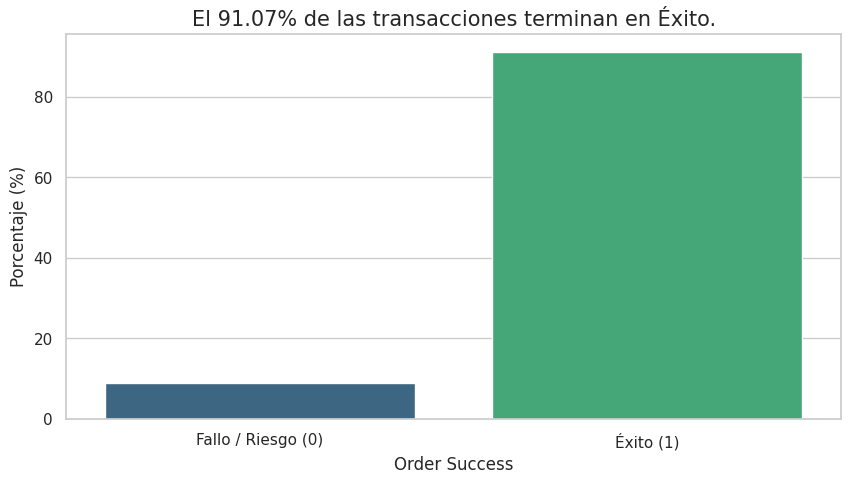

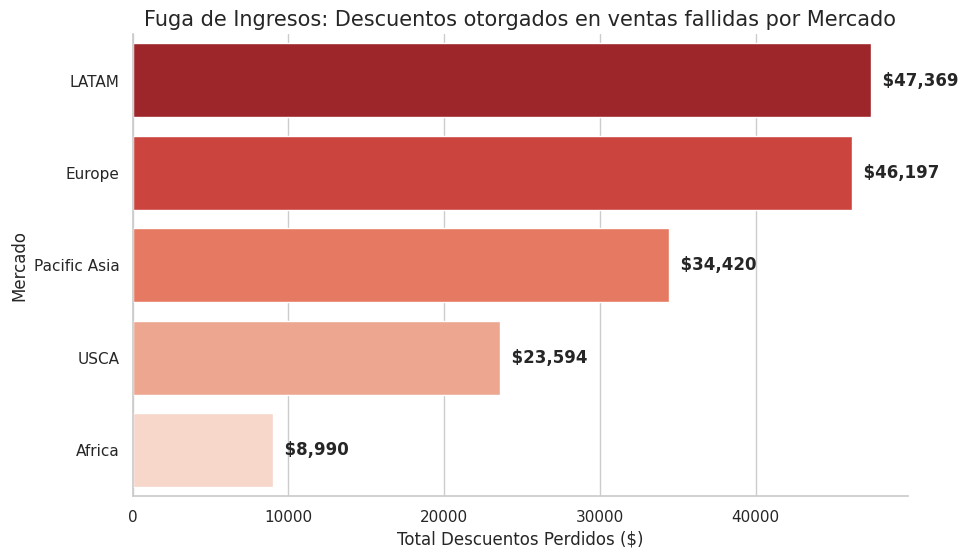

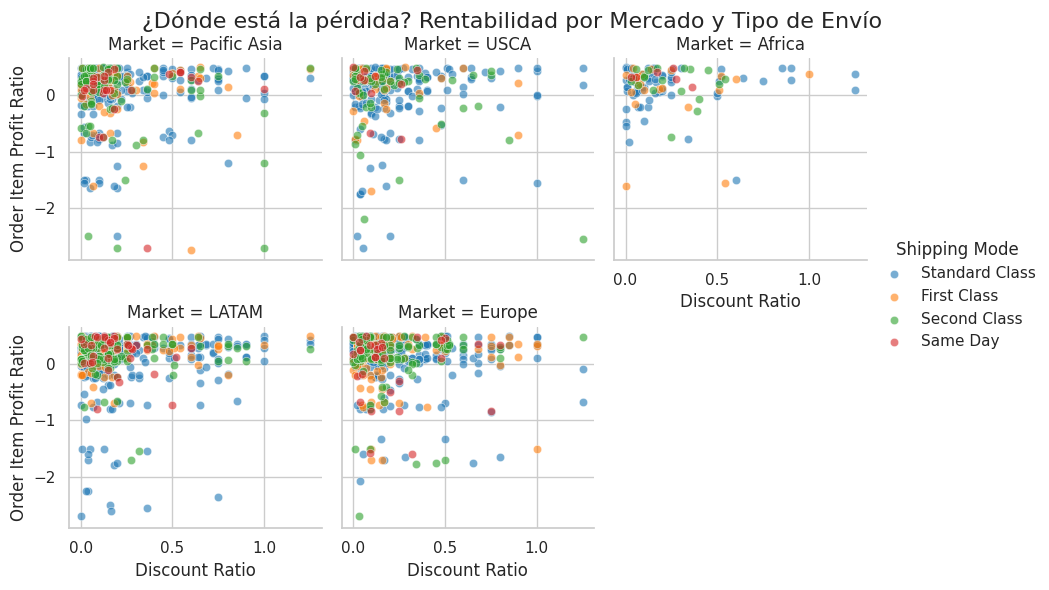

In [2]:
df_original["Discount Ratio"] = df_original["Order Item Discount"] / df_original["Product Price"]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 6]

success_counts = df_original["Order Success"].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=success_counts.index, y=success_counts.values, palette="viridis", hue=success_counts.index, legend=False)
plt.title(f"El {success_counts[1]:.2f}% de las transacciones terminan en Éxito.", fontsize=15)
plt.ylabel("Porcentaje (%)")
plt.xticks([0, 1], ["Fallo / Riesgo (0)", "Éxito (1)"])
plt.show()

lost_status = ["CANCELED", "SUSPECTED_FRAUD"]
df_lost = df_original[df_original["Order Status"].isin(lost_status)].copy()
discount_lost = df_lost.groupby("Market")["Order Item Discount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=discount_lost, x="Order Item Discount", y="Market", hue="Market", palette="Reds_r", legend=False)

for i, valor in enumerate(discount_lost["Order Item Discount"]):
    plt.text(valor, i, f'  ${valor:,.0f}', va="center", fontweight="bold")

plt.title("Fuga de Ingresos: Descuentos otorgados en ventas fallidas por Mercado", fontsize=15)
plt.xlabel("Total Descuentos Perdidos ($)")
plt.ylabel("Mercado")
sns.despine()
plt.show()

grid = sns.FacetGrid(df_original.sample(min(2000, len(df_original))), col="Market", hue="Shipping Mode", palette="tab10", col_wrap=3)
grid.map(sns.scatterplot, "Discount Ratio", "Order Item Profit Ratio", alpha=0.6)
grid.add_legend()
grid.fig.subplots_adjust(top=0.9)
grid.fig.suptitle("¿Dónde está la pérdida? Rentabilidad por Mercado y Tipo de Envío", fontsize=16)
plt.show()

#### Feature Engineering: estandarización, codificación y sobremuestreo
Este enfoque de preprocesamiento de variables se basa en el Análisis Exploratorio de Datos previo, diseñado para optimizar el rendimiento y la estabilidad del modelo optimiza el rendimiento del modelo al unificar la escala de los datos, estructurar variables cualitativas y balancear la representatividad de las clases. La combinación de estandarización, codificación One Hot y sobremuestreo previene el sesgo algorítmico, acelera la convergencia del entrenamiento y garantiza que las métricas de evaluación reflejen la capacidad real de generalización del modelo.


In [18]:
df = df_original.copy()
df.drop(columns=["Order Status","Order Item Discount"], inplace=True)
df = df.reset_index(drop=True)

categorical_vars = ["Category Name", "Market", "Order Region", "Shipping Mode"]
numeric_vars = ["Days for shipment (scheduled)", "Product Price", "Discount Ratio"]

X_train, X_test, y_train, y_test = train_test_split(df[categorical_vars + numeric_vars],
                                                    df["Order Success"],
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=df["Order Success"])

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_vars])
X_train_num = pd.DataFrame(X_train_num, columns=numeric_vars, index=X_train.index)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform="pandas")
X_train_cat = encoder.fit_transform(X_train[categorical_vars])

X_train_processed = pd.concat([X_train_cat, X_train_num], axis=1)

smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_processed_balanced, y_train = smote.fit_resample(X_train_processed, y_train)

display(Markdown("### Dataframe procesado (análisis predictivo)"))
display(X_train_processed_balanced)

### Dataframe procesado (análisis predictivo)

,Category Name_Accessories,Category Name_As Seen on TV!,Category Name_Baby,Category Name_Baseball & Softball,Category Name_Basketball,Category Name_Books,Category Name_Boxing & MMA,Category Name_CDs,Category Name_Cameras,Category Name_Camping & Hiking,...,Order Region_West Asia,Order Region_West of USA,Order Region_Western Europe,Shipping Mode_First Class,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class,Days for shipment (scheduled),Product Price,Discount Ratio
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.778364,0.416955,-0.794579
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-1.400599,1.126528,-0.879966
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.778364,-0.079796,-0.623797
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.400599,-0.647583,0.102347
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.778364,1.836173,-0.837273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79101,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.674278,-0.647583,0.554624
79102,0.0,0.0,0.0,0.0,0.0,0.498545,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.778364,-0.785549,-0.602110
79103,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-1.400599,-0.647441,2.615879
79104,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.778364,-0.576548,0.098452


#### Bagging (K-Neighbors): reforzando los casos más cercanos
Es una de las principales técnicas computacionales de estadística inferencial cuya objetivo se basa en eliminar o reducir lo máximo posible la varianza en los resultados, su método es utilizar la sabiduría de las masas, es decir, reforzar el aprendizaje mediante el criterio de distintos metaestimadores que se encargarán de sacar sus propias conclusiones de respectivos datos seleccionados para luego, dependiendo del problema en cuestión, llegar a una respuesta final a través de la media o moda del conjunto de resultados. Al entrenar múltiples modelos con datos ligeramente distintos y contar sus resultados, el Bagging suaviza estas fluctuaciones. La agregación de los resultados cancela la varianza individual de cada modelo, resultando en un modelo de conjunto con un error de varianza significativamente menor.

In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

bagging_knn = BaggingClassifier(estimator=knn_classifier,
                                n_estimators=100,
                                max_samples=0.3,
                                bootstrap=True,
                                random_state=42,
                                n_jobs=1)

bagging_knn.fit(X_train_processed_balanced, y_train)

new_object = df_original.sample(n=1)
new_object.drop(columns=["Order Status","Order Item Discount"], inplace=True)
new_object = new_object.reset_index(drop=True)

obj_num_scaled = scaler.transform(new_object[numeric_vars])
obj_cat_encoded = encoder.transform(new_object[categorical_vars])

object_processed = np.hstack((obj_cat_encoded, obj_num_scaled))

predict_proba = bagging_knn.predict_proba(object_processed)
fail_risk = predict_proba[0,0] * 100

display(Markdown("#### Nueva planificación comercial (ejemplo)"))
print("-" * 60)
display(Markdown(f"#### Riesgo de fracaso: {fail_risk:.2f}%"))

#### Nueva planificación comercial (ejemplo)

--------------------------------------------------


#### Riesgo de fracaso: 15.00%

#### Herramienta interactiva basada en un socring de riesgo en la ejecución de nuevas planficaciones comerciales

In [ ]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_train_processed)

df_pca = pd.DataFrame(pca_results, columns=["PC1", "PC2"])
df_pca["Order Success"] = y_train.values

success = df_pca.loc[df_pca["Order Success"] == 1,:]
fails = df_pca.loc[df_pca["Order Success"] == 0,:]

prc = df["Order Success"].value_counts(normalize=True)
success_prc = round(prc.get(1, 0) * 100, 1)
fails_prc = round(prc.get(0, 0) * 100, 1)

probability_text = html.B(id="probability", children=[], style={})

fig_pca = go.Figure()
fig_pca.add_trace(go.Scatter(x=success["PC1"], y=success["PC2"], mode="markers", marker_color="green", name=f"Completadas ({success_prc}%)"))
fig_pca.add_trace(go.Scatter(x=fails["PC1"], y=fails["PC2"], mode="markers", marker_color="red", name=f"Sin Éxito ({fails_prc}%)"))
fig_pca.update_layout(title="Resultados de Órdenes Históricas")
fig_pca.update_layout(legend=dict(font=dict(size=9)))

app = dash.Dash(__name__)

app.layout =  html.Div(id="body", className="e4_body", children=[
    html.H1("Evaluación de riesgo en planificaciones comerciales", id="title", className="e4_title"),
    html.Div(id="dashboard", className="e4_dashboard", children=[
        html.Div(className="e4_graph_div", children=[
            dcc.Graph(id="graph_pca", className="e4_graph", figure=fig_pca),
            html.Div(id="input_div", style={"display":"flex","flexWrap":"wrap","gap":"10px"}, children=[
                dcc.Input(id="input_1", type="number", placeholder="Días envío", style={"width":"75px"}),
                dcc.Input(id="input_5", type="number", placeholder="Precio Producto", style={"width":"75px"}),
                dcc.Input(id="input_6", type="number", placeholder="Ratio Descuento", style={"width":"75px"}),
                dcc.Dropdown(id="input_2", options=df_original["Market"].unique(), placeholder="Mercado", style={"width":"150px"}),
                dcc.Dropdown(id="input_3", options=df_original["Order Region"].unique(), placeholder="Región", style={"width":"150px"}),
                dcc.Dropdown(id="input_4", options=df_original["Category Name"].unique(), placeholder="Categoría", style={"width":"150px"}),
                dcc.Dropdown(id="input_7", options=df_original["Shipping Mode"].unique(), placeholder="Tipo Envío", style={"width":"150px"}),
                html.Button(id="button", className="e4_button", children="Enviar", n_clicks=0)
            ]),
            html.P(["predicción: riesgo de fracaso de ", probability_text,"%"], className="e4_predict")
        ])
    ])
])

@app.callback(
    [Output(component_id="graph_pca",component_property="figure"),
    Output(component_id="probability",component_property="children"),
    Output(component_id="probability",component_property="style")],
    [Input(component_id="button",component_property="n_clicks")],
    [State(component_id="input_1",component_property="value"),
    State(component_id="input_2",component_property="value"),
    State(component_id="input_3",component_property="value"),
    State(component_id="input_4",component_property="value"),
    State(component_id="input_5",component_property="value"),
    State(component_id="input_6",component_property="value"),
    State(component_id="input_7",component_property="value")]
)

def get_risk_prob(n_clicks, var_1, var_2, var_3, var_4, var_5, var_6, var_7):

    fig_update = go.Figure(fig_pca)
    prob_fail_text = "0.00%"
    style_res = {"color": "black"}

    inputs = [var_1, var_2, var_3, var_4, var_5, var_6, var_7]

    if n_clicks > 0 and all(v is not None for v in inputs):

        new_object = pd.DataFrame({
            "Days for shipment (scheduled)": [float(var_1)],
            "Market": [str(var_2)],
            "Order Region": [str(var_3)],
            "Category Name": [str(var_4)],
            "Product Price": [float(var_5)],
            "Discount Ratio": [float(var_6)],
            "Shipping Mode": [str(var_7)]
        })

        obj_num_scaled = scaler.transform(new_object[numeric_vars])
        obj_cat_encoded = encoder.transform(new_object[categorical_vars])

        object_processed = np.hstack((obj_cat_encoded, obj_num_scaled))

        prob_fail = bagging_knn.predict_proba(object_processed)[0,0] * 100
        prob_fail_text = f"{prob_fail:.2f}"

        if prob_fail <= 45:
            factor = prob_fail / 45
            hue = int(120 - (factor * 120))
            color_res = f"hsl({hue}, 100%, 45%)"
        elif 45 < prob_fail <= 50:
            color_res = "hsl(0, 100%, 45%)"
        else:
            dark_factor = (prob_fail - 50) / 50
            lightness = int(45 - (dark_factor * 25))
            color_res = f"hsl(0, 100%, {lightness}%)"

            style_res = {"color":color_res}

        obj_pca = pca.transform(object_processed)

        fig_update.add_trace(go.Scatter(
            x=[obj_pca[0,0]],
            y=[obj_pca[0,1]],
            mode="markers",
            marker=dict(color="blueviolet", size=15, symbol="star"),
            name="Nueva Órden"
        ))

    return fig_pca, prob_fail_text, style_res


if __name__ == "__main__":
    app.run(debug=False)